In [61]:
# Install and import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [62]:
#loading the file
import pandas as pd

df = pd.read_csv("/content/Data/Historic_HABs_Events_2015-2023.csv")

df.head(), df.columns

(             X            Y  OBJECTID             SAMPLE_DATE      TIME  \
 0  524174.4219  393179.5007    396562  2015/02/16 00:00:00+00  15:02:00   
 1  627186.1560  220879.1753    396563  2015/02/16 00:00:00+00  15:33:00   
 2  628350.8443  214141.7306    396564  2015/02/16 00:00:00+00  15:51:00   
 3  635057.4252  216598.3960    396565  2015/02/16 00:00:00+00  16:20:00   
 4  629630.5063  221712.4796    396566  2015/02/16 00:00:00+00  16:40:00   
 
   TIMEZONE  DEPTH                                           LOCATION  \
 0      GMT    0.5  Anna Maria Island Rod & Reel Pier (Lower Tampa...   
 1      GMT    0.5           Lee Avenue; docks NE of (Big Marco Pass)   
 2      GMT    0.5                                      Caxambas Park   
 3      GMT    0.5                                    Goodland Bridge   
 4      GMT    0.5                     951 Boat Ramp (Big Marco Pass)   
 
    LATITUDE  LONGITUDE            NAME  COUNT_          HAB_ID  
 0   27.5385   -82.7402  Karenia bre

In [63]:
# Basic date features
dt = pd.to_datetime(df["SAMPLE_DATE"])

df["date"] = dt.dt.date
df["year"] = dt.dt.year
df["month"] = dt.dt.month
df["dayofyear"] = dt.dt.dayofyear

print(df[["SAMPLE_DATE", "date", "year", "month", "dayofyear"]].head())

              SAMPLE_DATE        date  year  month  dayofyear
0  2015/02/16 00:00:00+00  2015-02-16  2015      2         47
1  2015/02/16 00:00:00+00  2015-02-16  2015      2         47
2  2015/02/16 00:00:00+00  2015-02-16  2015      2         47
3  2015/02/16 00:00:00+00  2015-02-16  2015      2         47
4  2015/02/16 00:00:00+00  2015-02-16  2015      2         47


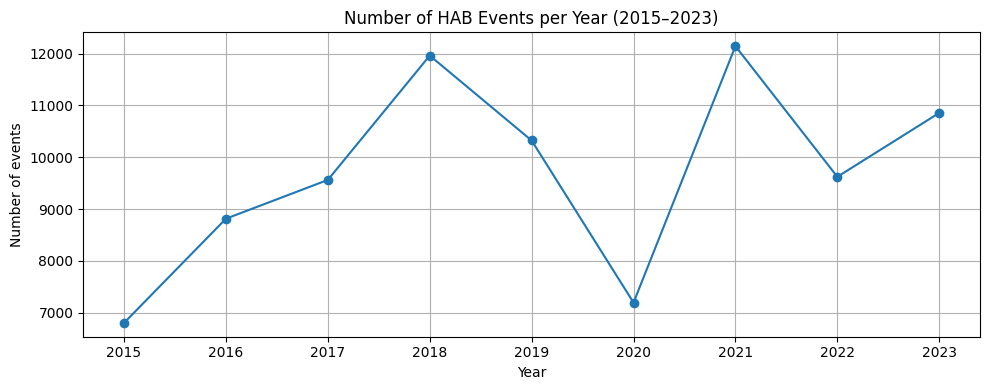

In [64]:
# NUmber of HAB events per year
events_per_year = df.groupby("year").size()

plt.figure(figsize=(10,4))
plt.plot(events_per_year.index, events_per_year.values, marker="o")
plt.title("Number of HAB Events per Year (2015–2023)")
plt.xlabel("Year")
plt.ylabel("Number of events")
plt.grid(True)
plt.tight_layout()
plt.show()

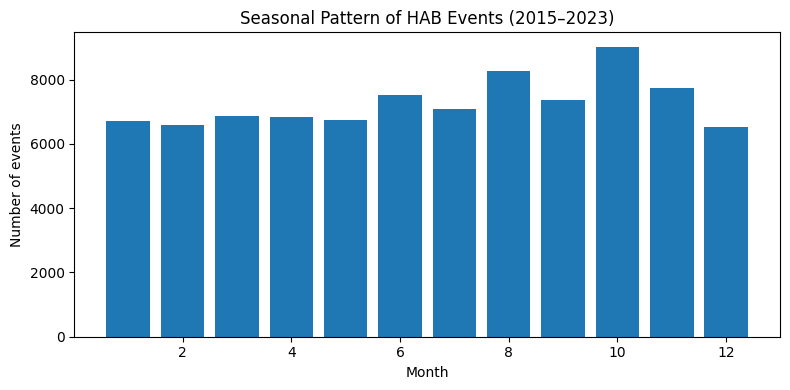

,0
month,
1,6711
2,6603
3,6864
4,6827
5,6747
6,7514
7,7100
8,8261
9,7362


In [65]:
# Seasonal pattern (events per month)
events_per_month = df.groupby("month").size()

plt.figure(figsize=(8,4))
plt.bar(events_per_month.index, events_per_month.values)
plt.title("Seasonal Pattern of HAB Events (2015–2023)")
plt.xlabel("Month")
plt.ylabel("Number of events")
plt.tight_layout()
plt.show()

events_per_month

In [67]:
# Build a daily dataset for modeling
# We’ll aggregate to daily counts, then make a binary label:
# has_event = 1 if that day had ≥1 event, else 0.

# 1. Daily event counts from the original df
daily_counts = (
    df.groupby("date")
      .size()
      .reset_index(name="events")
)

# Ensure daily_counts['date'] is datetime
daily_counts["date"] = pd.to_datetime(daily_counts["date"])

# 2. Full daily date range
full_dates = pd.date_range(
    daily_counts["date"].min(),
    daily_counts["date"].max(),
    freq="D"
)

daily_full = pd.DataFrame({"date": full_dates})

# 3. Merge counts into full calendar
daily_full = daily_full.merge(daily_counts, on="date", how="left")
daily_full["events"] = daily_full["events"].fillna(0)

# 4. Date features again
dt_daily = pd.to_datetime(daily_full["date"])
daily_full["year"] = dt_daily.dt.year
daily_full["month"] = dt_daily.dt.month
daily_full["dayofyear"] = dt_daily.dt.dayofyear

# 5. Binary label: did any HAB event happen this day?
daily_full["has_event"] = (daily_full["events"] > 0).astype(int)

daily_full.head(), daily_full["has_event"].value_counts()

(        date  events  year  month  dayofyear  has_event
 0 2015-01-02     7.0  2015      1          2          1
 1 2015-01-03     0.0  2015      1          3          0
 2 2015-01-04     1.0  2015      1          4          1
 3 2015-01-05    50.0  2015      1          5          1
 4 2015-01-06     5.0  2015      1          6          1,
 has_event
 1    3120
 0     165
 Name: count, dtype: int64)

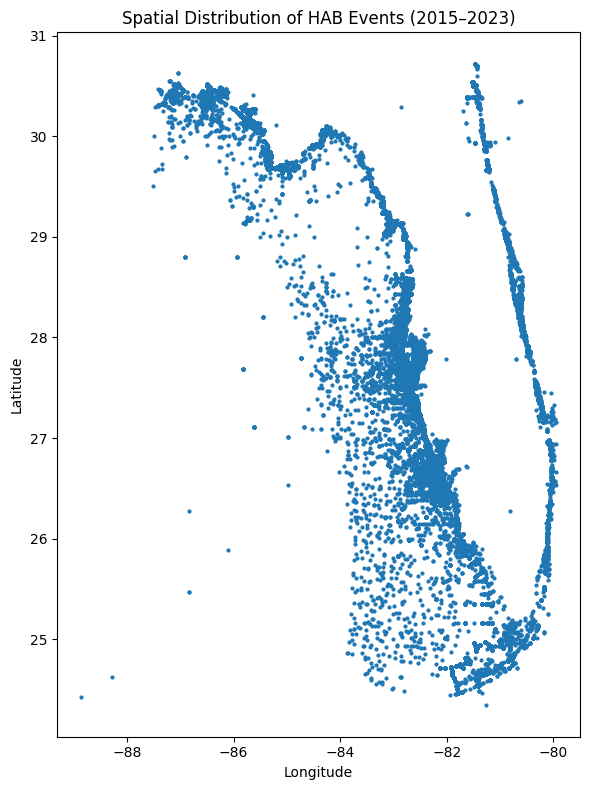

In [68]:
#Spatial distribution (use LATITUDE / LONGITUDE)
plt.figure(figsize=(6,8))
plt.scatter(df["LONGITUDE"], df["LATITUDE"], s=4)
plt.title("Spatial Distribution of HAB Events (2015–2023)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [69]:
# Logistic regression: does month predict HAB-event days?

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# One-hot encode month
X = pd.get_dummies(daily_full["month"], prefix="month", drop_first=True)
y = daily_full["has_event"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.949290060851927

Confusion matrix:
 [[  0  50]
 [  0 936]]

Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.95      1.00      0.97       936

    accuracy                           0.95       986
   macro avg       0.47      0.50      0.49       986
weighted avg       0.90      0.95      0.92       986



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


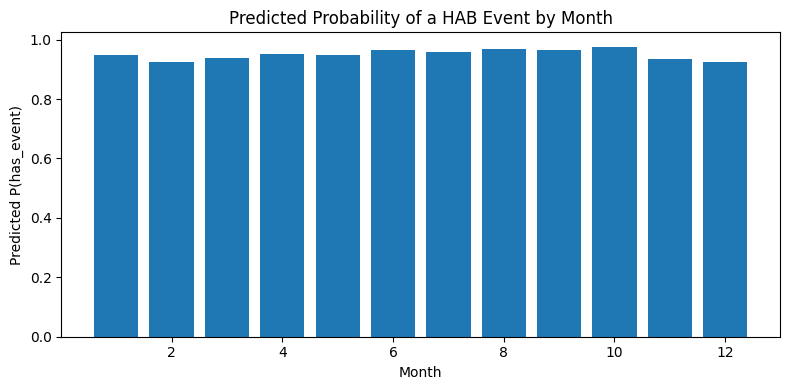

,month,pred_prob
0,1,0.948175
1,2,0.923812
2,3,0.937572
3,4,0.950552
4,5,0.949565
5,6,0.965713
6,7,0.959487
7,8,0.967346
8,9,0.964579
9,10,0.975881


In [71]:
# Predicted probability of an event by month
# Month grid 1..12
month_grid = pd.DataFrame({"month": range(1, 13)})
X_month = pd.get_dummies(month_grid["month"], prefix="month", drop_first=True)

# Align columns with training data
for col in X_train.columns:
    if col not in X_month.columns:
        X_month[col] = 0
X_month = X_month[X_train.columns]

# Predicted probability of has_event = 1
month_grid["pred_prob"] = model.predict_proba(X_month)[:, 1]

plt.figure(figsize=(8,4))
plt.bar(month_grid["month"], month_grid["pred_prob"])
plt.title("Predicted Probability of a HAB Event by Month")
plt.xlabel("Month")
plt.ylabel("Predicted P(has_event)")
plt.tight_layout()
plt.show()

month_grid

In [72]:
# Because of the imbalace data, we want look more closely and restricting to one region which is Sarasota bay
# filter datasets
df_sarasota = df[df["LOCATION"].str.contains("Sarasota", case=False, na=False)]
df_sarasota.head(), df_sarasota.shape

(             X            Y  OBJECTID             SAMPLE_DATE TIME TIMEZONE  \
 5  540804.7940  372828.3420    396567  2015/02/03 00:00:00+00  NaN      GMT   
 6  541543.7877  371434.3578    396568  2015/02/03 00:00:00+00  NaN      GMT   
 7  540227.1395  370686.2004    396569  2015/02/03 00:00:00+00  NaN      GMT   
 8  541807.7317  368018.2397    396570  2015/02/03 00:00:00+00  NaN      GMT   
 9  542607.1506  367741.0693    396571  2015/02/03 00:00:00+00  NaN      GMT   
 
    DEPTH                           LOCATION  LATITUDE  LONGITUDE  \
 5    1.0   City Island; N of (Sarasota Bay)  27.35361  -82.57388   
 6    1.0  City Island; NE of (Sarasota Bay)  27.34098  -82.56656   
 7    1.0            New Pass (Sarasota Bay)  27.33438  -82.57998   
 8    1.0      Bird Key; W of (Sarasota Bay)  27.31019  -82.56429   
 9    1.0    Bay Island; N of (Sarasota Bay)  27.30761  -82.55623   
 
              NAME  COUNT_          HAB_ID        date  year  month  dayofyear  
 5  Karenia brevis   

In [73]:
# Create daily counts again
daily_counts = (
    df_sarasota.groupby("date")
      .size()
      .reset_index(name="events")
)

daily_counts["date"] = pd.to_datetime(daily_counts["date"])

full_dates = pd.date_range(daily_counts["date"].min(),
                           daily_counts["date"].max(), freq="D")

daily_full = pd.DataFrame({"date": full_dates})
daily_full = daily_full.merge(daily_counts, on="date", how="left")
daily_full["events"] = daily_full["events"].fillna(0)

# Features
dt = pd.to_datetime(daily_full["date"])
daily_full["month"] = dt.dt.month

# Target for modeling
daily_full["has_event"] = (daily_full["events"] > 0).astype(int)

daily_full["has_event"].value_counts()

,count
has_event,
1,1891
0,1393


In [74]:
# Re running the logistic regreesion on Sarasota Bay Subset

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features & target
X = pd.get_dummies(daily_full["month"], prefix="month", drop_first=True)
y = daily_full["has_event"]

# Stratified split since classes are now balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5760649087221096

Confusion matrix:
 [[  0 418]
 [  0 568]]

Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       418
           1       0.58      1.00      0.73       568

    accuracy                           0.58       986
   macro avg       0.29      0.50      0.37       986
weighted avg       0.33      0.58      0.42       986



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


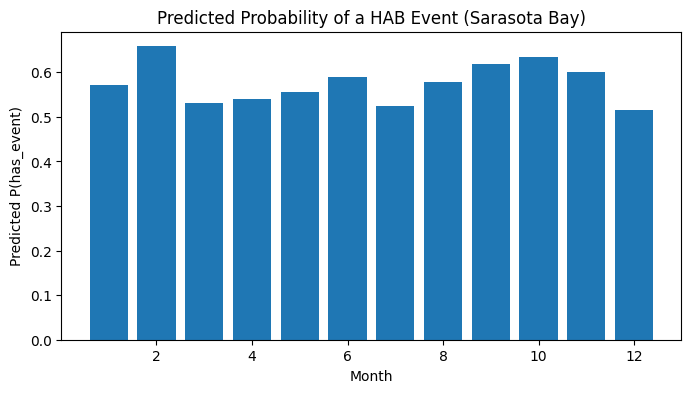

,month,pred_prob
0,1,0.571188
1,2,0.658060
2,3,0.530213
3,4,0.540011
4,5,0.555190
5,6,0.589083
6,7,0.523492
7,8,0.578755
8,9,0.618351
9,10,0.634547


In [75]:
# Predicted probability by month

month_grid = pd.DataFrame({"month": range(1, 13)})
X_month = pd.get_dummies(month_grid["month"], prefix="month", drop_first=True)

# Align columns
for col in X_train.columns:
    if col not in X_month.columns:
        X_month[col] = 0
X_month = X_month[X_train.columns]

month_grid["pred_prob"] = model.predict_proba(X_month)[:, 1]

plt.figure(figsize=(8,4))
plt.bar(month_grid["month"], month_grid["pred_prob"])
plt.title("Predicted Probability of a HAB Event (Sarasota Bay)")
plt.xlabel("Month")
plt.ylabel("Predicted P(has_event)")
plt.show()

month_grid

In [76]:
# Random Forest
# set up shared features fo random forest
# make sure date is datetime
daily_full["date"] = pd.to_datetime(daily_full["date"])

# add day-of-year feature
daily_full["dayofyear"] = daily_full["date"].dt.dayofyear

daily_full[["date", "month", "dayofyear"]].head()



,date,month,dayofyear
0,2015-01-02,1,2
1,2015-01-03,1,3
2,2015-01-04,1,4
3,2015-01-05,1,5
4,2015-01-06,1,6


In [ ]:
# FEATURE MATRIX
X_month = pd.get_dummies(daily_full["month"], prefix="month", drop_first=True)
X = pd.concat([X_month, daily_full[["dayofyear"]]], axis=1)

# TARGET
y = daily_full["has_event"]

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [77]:
# Random Forest model (Baseline 2)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5760649087221096

Confusion matrix:
 [[  0 418]
 [  0 568]]

Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       418
           1       0.58      1.00      0.73       568

    accuracy                           0.58       986
   macro avg       0.29      0.50      0.37       986
weighted avg       0.33      0.58      0.42       986



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [78]:
#Re-create the Sarasota daily dataset
# 1. Filter Sarasota-only rows
sarasota_df = df[df["LOCATION"].str.contains("Sarasota", case=False, na=False)].copy()

# 2. Create date column
sarasota_df["date"] = pd.to_datetime(sarasota_df["SAMPLE_DATE"])

# 3. Daily event count
daily_sara = sarasota_df.groupby("date").size().reset_index(name="events")

# 4. Create full date range
full_dates = pd.date_range(daily_sara["date"].min(), daily_sara["date"].max(), freq="D")
daily_full = pd.DataFrame({"date": full_dates})

# 5. Merge & fill missing days
daily_full = daily_full.merge(daily_sara, on="date", how="left")
daily_full["events"] = daily_full["events"].fillna(0)

# 6. Feature engineering
daily_full["month"] = daily_full["date"].dt.month
daily_full["dayofyear"] = daily_full["date"].dt.dayofyear
daily_full["has_event"] = (daily_full["events"] > 0).astype(int)

daily_full.head()

,date,events,month,dayofyear,has_event
0,2015-01-02 00:00:00+00:00,2.0,1,2,1
1,2015-01-03 00:00:00+00:00,0.0,1,3,0
2,2015-01-04 00:00:00+00:00,0.0,1,4,0
3,2015-01-05 00:00:00+00:00,3.0,1,5,1
4,2015-01-06 00:00:00+00:00,2.0,1,6,1


In [79]:
#Sample of daily aggregated HAB dataset (table)
daily_full.head()

,date,events,month,dayofyear,has_event
0,2015-01-02 00:00:00+00:00,2.0,1,2,1
1,2015-01-03 00:00:00+00:00,0.0,1,3,0
2,2015-01-04 00:00:00+00:00,0.0,1,4,0
3,2015-01-05 00:00:00+00:00,3.0,1,5,1
4,2015-01-06 00:00:00+00:00,2.0,1,6,1


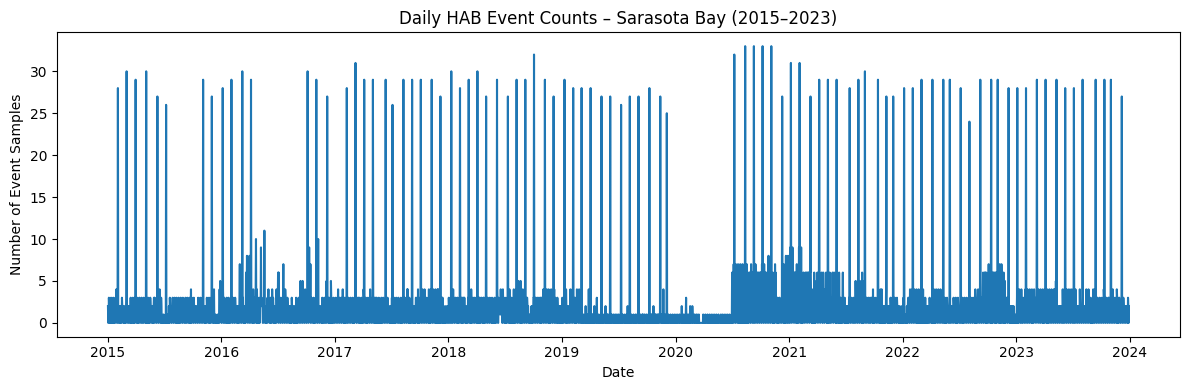

In [80]:
#Daily time series plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(daily_full["date"], daily_full["events"])
plt.title("Daily HAB Event Counts – Sarasota Bay (2015–2023)")
plt.xlabel("Date")
plt.ylabel("Number of Event Samples")
plt.tight_layout()
plt.show()

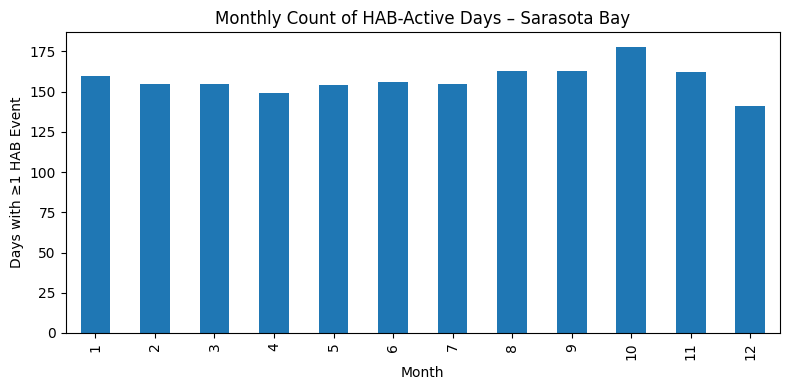

In [81]:
#Monthly distribution (Bar chart)
monthly_counts = daily_full.groupby("month")["has_event"].sum()

plt.figure(figsize=(8,4))
monthly_counts.plot(kind="bar")
plt.title("Monthly Count of HAB-Active Days – Sarasota Bay")
plt.xlabel("Month")
plt.ylabel("Days with ≥1 HAB Event")
plt.tight_layout()
plt.show()

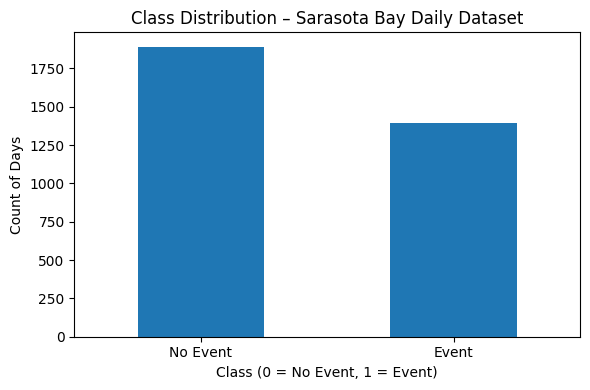

In [82]:
# Class distribution (0 vs 1)
daily_full["has_event"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Class Distribution – Sarasota Bay Daily Dataset")
plt.xlabel("Class (0 = No Event, 1 = Event)")
plt.ylabel("Count of Days")
plt.xticks([0,1], ["No Event","Event"], rotation=0)
plt.tight_layout()
plt.show()

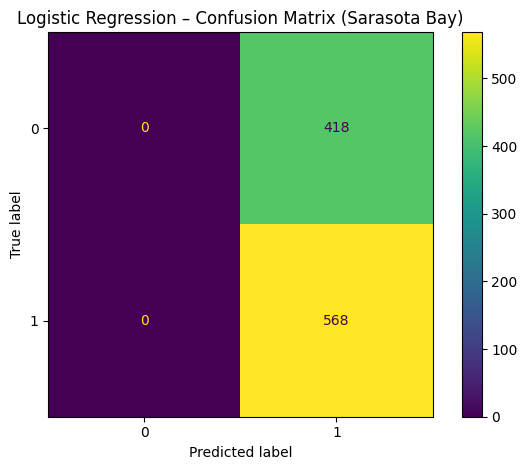

In [83]:
# logistic regression confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Logistic Regression – Confusion Matrix (Sarasota Bay)")
plt.tight_layout()
plt.show()

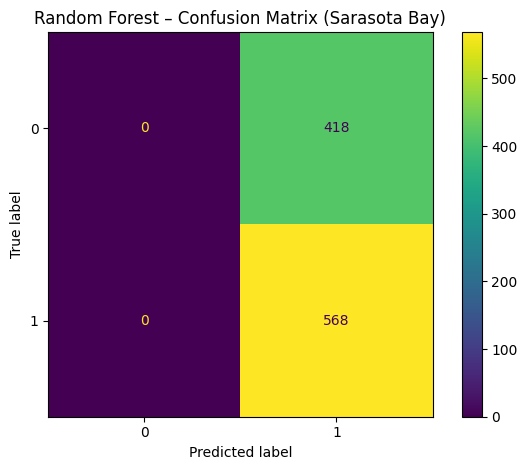

In [84]:
# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest – Confusion Matrix (Sarasota Bay)")
plt.tight_layout()
plt.show()

In [87]:
#using enviornmental data
import pandas as pd

sst = pd.read_csv("/content/Data/sst_sarasota.csv")

col = sst.columns[0]   # the first column is the timestamp

sst[col] = pd.to_datetime(sst[col], errors="coerce")
sst = sst.rename(columns={col: "date"})

sst.head()

/tmp/ipython-input-658372723.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sst[col] = pd.to_datetime(sst[col], errors="coerce")


,date,zlev,latitude,longitude,sst
0,NaT,m,degrees_north,degrees_east,degree_C
1,2015-01-01 12:00:00+00:00,0.0,27.125,277.375,20.93
2,2015-01-02 12:00:00+00:00,0.0,27.125,277.375,21.19
3,2015-01-03 12:00:00+00:00,0.0,27.125,277.375,21.29
4,2015-01-04 12:00:00+00:00,0.0,27.125,277.375,21.42


In [88]:
sst = sst.dropna(subset=["date"]).reset_index(drop=True)
sst.head()

,date,zlev,latitude,longitude,sst
0,2015-01-01 12:00:00+00:00,0.0,27.125,277.375,20.93
1,2015-01-02 12:00:00+00:00,0.0,27.125,277.375,21.19
2,2015-01-03 12:00:00+00:00,0.0,27.125,277.375,21.29
3,2015-01-04 12:00:00+00:00,0.0,27.125,277.375,21.42
4,2015-01-05 12:00:00+00:00,0.0,27.125,277.375,21.41


In [92]:
import pandas as pd

# Load HAB dataset
df = pd.read_csv("/content/Data/Historic_HABs_Events_2015-2023.csv")
df.head()
# Filter Sarasota-only rows
sarasota_df = df[df["LOCATION"].str.contains("Sarasota", case=False, na=False)].copy()
sarasota_df.head()
sarasota_df["date"] = pd.to_datetime(sarasota_df["SAMPLE_DATE"])
daily_sara = sarasota_df.groupby("date").size().reset_index(name="events")
daily_sara.head()
full_dates = pd.date_range(
    start=daily_sara["date"].min(),
    end=daily_sara["date"].max(),
    freq="D"
)

daily_full = pd.DataFrame({"date": full_dates})
daily_full = daily_full.merge(daily_sara, on="date", how="left")
daily_full["events"] = daily_full["events"].fillna(0)
daily_full["month"] = daily_full["date"].dt.month
daily_full["dayofyear"] = daily_full["date"].dt.dayofyear
daily_full["has_event"] = (daily_full["events"] > 0).astype(int)
merged = daily_full.merge(sst[["date", "sst"]], on="date", how="left")
merged.head()

,date,events,month,dayofyear,has_event,sst
0,2015-01-02 00:00:00+00:00,2.0,1,2,1,NaN
1,2015-01-03 00:00:00+00:00,0.0,1,3,0,NaN
2,2015-01-04 00:00:00+00:00,0.0,1,4,0,NaN
3,2015-01-05 00:00:00+00:00,3.0,1,5,1,NaN
4,2015-01-06 00:00:00+00:00,2.0,1,6,1,NaN


In [93]:
#Helper function to clean Giovanni time-series CSVs
import pandas as pd

# path assumes your notebook is in the same folder that contains the "Data" folder
DATA_DIR = "Data"

def clean_giovanni_timeseries(filename, value_name):
    """
    filename   : CSV file name inside the Data folder
    value_name : how you want to name the numeric column (e.g. 'chl_a', 'kd490')
    """
    path = f"{DATA_DIR}/{filename}"

    # Read without header so we can find where the real header is
    raw = pd.read_csv(path, header=None)

    # Find the row index where the first column is exactly 'time'
    header_idx = raw.index[raw[0] == "time"][0]

    # Data starts on the next row; keep only the first two columns (time + value)
    data = raw.iloc[header_idx + 1:, [0, 1]].copy()
    data.columns = ["date", value_name]

    # Convert to proper types
    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data[value_name] = pd.to_numeric(data[value_name], errors="coerce")

    # Drop any rows where date is missing
    data = data.dropna(subset=["date"]).reset_index(drop=True)

    # Get rid of any timezone info just in case
    data["date"] = data["date"].dt.tz_localize(None)

    return data

In [94]:
# Clean chlorophyll-a time series
chl = clean_giovanni_timeseries("chl_a_FL_2018_2023.csv", "chl_a")
chl.head()

,date,chl_a
0,2018-01-01,3.290678
1,2018-02-01,2.112855
2,2018-03-01,1.836619
3,2018-04-01,1.492735
4,2018-05-01,1.252793


In [95]:
# Clean KD490 time series
kd = clean_giovanni_timeseries("kd490_FL_2018_2023.csv", "kd490")
kd.head()

,date,kd490
0,2018-01-01,0.253386
1,2018-02-01,0.165948
2,2018-03-01,0.150222
3,2018-04-01,0.128710
4,2018-05-01,0.115281


In [96]:
# Convert to daily frequency with forward-fill
chl_daily = (
    chl.set_index("date")
       .resample("D")
       .ffill()
       .reset_index()
)

kd_daily = (
    kd.set_index("date")
      .resample("D")
      .ffill()
      .reset_index()
)

chl_daily.head(), kd_daily.head()

(        date     chl_a
 0 2018-01-01  3.290678
 1 2018-01-02  3.290678
 2 2018-01-03  3.290678
 3 2018-01-04  3.290678
 4 2018-01-05  3.290678,
         date     kd490
 0 2018-01-01  0.253386
 1 2018-01-02  0.253386
 2 2018-01-03  0.253386
 3 2018-01-04  0.253386
 4 2018-01-05  0.253386)

In [97]:
# Clean SST and aggregate to daily
import pandas as pd

# Load SST
sst_raw = pd.read_csv("Data/sst_sarasota.csv")

# Drop the units row (where time == "UTC")
sst = sst_raw[sst_raw["time"] != "UTC"].copy()

# Parse time and convert to daily date
sst["date"] = pd.to_datetime(sst["time"], errors="coerce")
sst["date"] = sst["date"].dt.floor("D")   # strip time-of-day

# Keep only the SST column and convert to numeric
sst["sst"] = pd.to_numeric(sst["sst"], errors="coerce")

# Daily mean SST (just in case there are multiple times per day)
sst_daily = (
    sst.groupby("date", as_index=False)["sst"]
       .mean()
       .sort_values("date")
)

print(sst_daily.head())
print("SST daily shape:", sst_daily.shape)

                       date    sst
0 2015-01-01 00:00:00+00:00  20.93
1 2015-01-02 00:00:00+00:00  21.19
2 2015-01-03 00:00:00+00:00  21.29
3 2015-01-04 00:00:00+00:00  21.42
4 2015-01-05 00:00:00+00:00  21.41
SST daily shape: (3283, 2)


In [98]:
#Normalize ALL date columns to the same type
def make_naive_date(df, col="date"):
    # Parse as datetime with UTC, then drop timezone
    df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")
    df[col] = df[col].dt.tz_convert(None)
    return df

# Apply to ALL relevant dataframes
daily_full = make_naive_date(daily_full, "date")
sst_daily  = make_naive_date(sst_daily,  "date")
chl_daily  = make_naive_date(chl_daily,  "date")
kd_daily   = make_naive_date(kd_daily,   "date")

print("daily_full date dtype:", daily_full["date"].dtype)
print("sst_daily   date dtype:", sst_daily["date"].dtype)
print("chl_daily   date dtype:", chl_daily["date"].dtype)
print("kd_daily    date dtype:", kd_daily["date"].dtype)

daily_full date dtype: datetime64[ns]
sst_daily   date dtype: datetime64[ns]
chl_daily   date dtype: datetime64[ns]
kd_daily    date dtype: datetime64[ns]


In [99]:
# building the merged dataset from scratch
# Start from HAB daily cleaned events dataframe
merged = daily_full.copy()
merged["date"] = pd.to_datetime(merged["date"])

# Merge SST first (always)
merged = merged.merge(sst_daily, on="date", how="left")

# Merge chlorophyll
merged = merged.merge(chl_daily, on="date", how="left")

# Merge KD490
merged = merged.merge(kd_daily, on="date", how="left")

# Final tidy
merged = merged.sort_values("date").reset_index(drop=True)

print("merged shape:", merged.shape)
print(merged.head())
print("NA counts:\n", merged.isna().sum())

merged shape: (3284, 8)
        date  events  month  dayofyear  has_event    sst  chl_a  kd490
0 2015-01-02     2.0      1          2          1  21.19    NaN    NaN
1 2015-01-03     0.0      1          3          0  21.29    NaN    NaN
2 2015-01-04     0.0      1          4          0  21.42    NaN    NaN
3 2015-01-05     3.0      1          5          1  21.41    NaN    NaN
4 2015-01-06     2.0      1          6          1  21.14    NaN    NaN
NA counts:
 date            0
events          0
month           0
dayofyear       0
has_event       0
sst             4
chl_a        1123
kd490        1123
dtype: int64


In [100]:
# filtering where all environmental predictors exist:
df = merged[merged["date"] >= "2018-01-01"].dropna().reset_index(drop=True)
print(df.shape)
df.head()

(2157, 8)


,date,events,month,dayofyear,has_event,sst,chl_a,kd490
0,2018-01-01,0.0,1,1,0,20.96,3.290678,0.253386
1,2018-01-02,3.0,1,2,1,19.95,3.290678,0.253386
2,2018-01-03,2.0,1,3,1,19.06,3.290678,0.253386
3,2018-01-04,2.0,1,4,1,18.92,3.290678,0.253386
4,2018-01-05,2.0,1,5,1,19.12,3.290678,0.253386


In [101]:
#feature engineering
import numpy as np

df_fe = df.copy()

# Extra temporal features
df_fe["dow"] = df_fe["date"].dt.weekday      # day of week (0=Mon)
df_fe["sin_doy"] = np.sin(2 * np.pi * df_fe["dayofyear"] / 365.25)
df_fe["cos_doy"] = np.cos(2 * np.pi * df_fe["dayofyear"] / 365.25)

# Short-term lags of has_event
for lag in [1, 7]:
    df_fe[f"has_event_lag{lag}"] = df_fe["has_event"].shift(lag)

# Drop rows with NaNs in features/label (mainly from lags at start)
feature_cols = [
    "month", "dayofyear", "dow",
    "sin_doy", "cos_doy",
    "sst", "chl_a", "kd490",
    "has_event_lag1", "has_event_lag7",
]
target_col = "has_event"

df_model = df_fe.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
print("df_model shape:", df_model.shape)
df_model.head()

df_model shape: (2150, 13)


,date,events,month,dayofyear,has_event,sst,chl_a,kd490,dow,sin_doy,cos_doy,has_event_lag1,has_event_lag7
0,2018-01-08,3.0,1,8,1,17.63,3.290678,0.253386,0,0.137185,0.990545,0.0,0.0
1,2018-01-09,3.0,1,9,1,17.69,3.290678,0.253386,1,0.154204,0.988039,1.0,1.0
2,2018-01-10,30.0,1,10,1,18.02,3.290678,0.253386,2,0.171177,0.985240,1.0,1.0
3,2018-01-11,2.0,1,11,1,18.38,3.290678,0.253386,3,0.188099,0.982150,1.0,1.0
4,2018-01-12,0.0,1,12,0,18.28,3.290678,0.253386,4,0.204966,0.978769,1.0,1.0


In [102]:
# Modeling – Phase 1 (Logistic Regression + Random Forest)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

X = df_model[feature_cols]
y = df_model[target_col]

# time-aware train/test split (first 80% train, last 20% test)
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Logistic regression baseline
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)
proba_lr = log_reg.predict_proba(X_test)[:, 1]
print("Logistic ROC-AUC:", roc_auc_score(y_test, proba_lr))

# Random forest model
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    class_weight="balanced"
)
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]
print("Random Forest ROC-AUC:", roc_auc_score(y_test, proba_rf))
print(classification_report(y_test, (proba_rf > 0.5).astype(int)))

Train shape: (1720, 10)
Test shape: (430, 10)
Logistic ROC-AUC: 0.9111079164270653
Random Forest ROC-AUC: 0.9300963197239793
              precision    recall  f1-score   support

           0       0.92      0.82      0.86       148
           1       0.91      0.96      0.93       282

    accuracy                           0.91       430
   macro avg       0.91      0.89      0.90       430
weighted avg       0.91      0.91      0.91       430



In [103]:
# building Phase 2 dataset
import numpy as np

df_fe = df.copy()

# Day of week
df_fe["dow"] = df_fe["date"].dt.weekday
df_fe["sin_doy"] = np.sin(2*np.pi*df_fe["dayofyear"]/365.25)
df_fe["cos_doy"] = np.cos(2*np.pi*df_fe["dayofyear"]/365.25)

# Lags (very important for XGBoost & LSTM)
for lag in [1, 7, 14]:
    df_fe[f"lag_event_{lag}"] = df_fe["has_event"].shift(lag)

df_fe = df_fe.dropna().reset_index(drop=True)


In [104]:
#feature list for phase 2
feature_cols = [
    "sst", "chl_a", "kd490",
    "month", "dow",
    "sin_doy", "cos_doy",
    "lag_event_1", "lag_event_7", "lag_event_14"
]
target = "has_event"

In [105]:
# Train/test split (time-aware):
split_idx = int(len(df_fe)*0.8)
X_train, X_test = df_fe[feature_cols].iloc[:split_idx], df_fe[feature_cols].iloc[split_idx:]
y_train, y_test = df_fe[target].iloc[:split_idx], df_fe[target].iloc[split_idx:]

In [106]:
# XGBoost
!pip install xgboost

In [107]:
# Train Model
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
)

xgb_model.fit(X_train, y_train)

proba_xgb = xgb_model.predict_proba(X_test)[:,1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, proba_xgb))
print(classification_report(y_test, (proba_xgb > 0.5).astype(int)))

XGBoost ROC-AUC: 0.916538424545542
              precision    recall  f1-score   support

           0       0.94      0.82      0.87       148
           1       0.91      0.97      0.94       281

    accuracy                           0.92       429
   macro avg       0.92      0.89      0.91       429
weighted avg       0.92      0.92      0.92       429



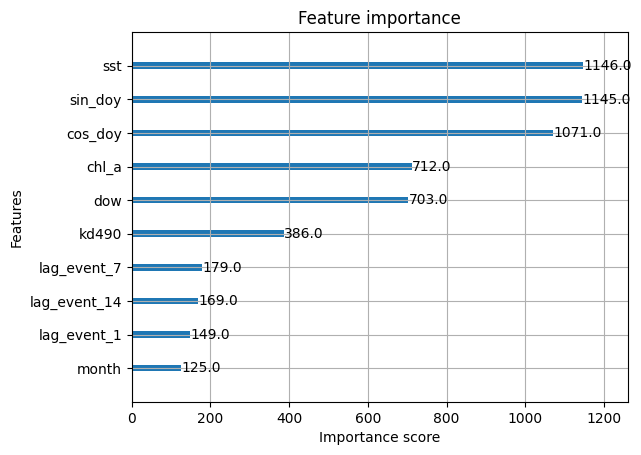

In [108]:
# XGBoost Feature Importance Plot
import matplotlib.pyplot as plt

xgb.plot_importance(xgb_model, max_num_features=10)
plt.show()

In [109]:
#PHASE 2 MODEL 2 — LSTM Sequence Model
# create sliding windows
import numpy as np

SEQ_LEN = 14  # using last 14 days to predict next-day bloom

# Convert full feature dataframe into sequences
def create_sequences(df, features, target, seq_len=14):
    X, y = [], []
    for i in range(len(df)-seq_len):
        X.append(df[features].iloc[i:i+seq_len].values)
        y.append(df[target].iloc[i+seq_len])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(df_fe, feature_cols, target, SEQ_LEN)

In [110]:
#Train/Test split for sequences
split_idx = int(len(X_seq)*0.8)

X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]

In [111]:
# Build and Train LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(SEQ_LEN, len(feature_cols))),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    verbose=1
)

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4974 - loss: 0.7377 - val_accuracy: 0.5865 - val_loss: 0.6791
Epoch 2/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5293 - loss: 0.6876 - val_accuracy: 0.5015 - val_loss: 0.6986
Epoch 3/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5705 - loss: 0.6716 - val_accuracy: 0.5308 - val_loss: 0.6800
Epoch 4/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6206 - loss: 0.6465 - val_accuracy: 0.5894 - val_loss: 0.6681
Epoch 5/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6983 - loss: 0.5959 - val_accuracy: 0.6246 - val_loss: 0.6370
Epoch 6/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7088 - loss: 0.5753 - val_accuracy: 0.6569 - val_loss: 0.5946
Epoch 7/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7696 - loss: 0.4829 - val_accuracy: 0.8123 - val_loss: 0.4947
Epoch 8/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8228 - loss: 0.4464 - val_accuracy: 0.8270 - val_loss: 0.

In [45]:
# LSTM evaluation
proba_lstm = model.predict(X_test_seq).flatten()

from sklearn.metrics import roc_auc_score
print("LSTM ROC-AUC:", roc_auc_score(y_test_seq, proba_lstm))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
LSTM ROC-AUC: 0.8862191679960729


In [119]:
# ========= 1. Feature engineering on df =========
import numpy as np
import pandas as pd

# Make a fresh copy so we don't accidentally modify df elsewhere
df_fe = df.copy()

# Day-of-week (0=Mon,…,6=Sun)
df_fe["dow"] = df_fe["date"].dt.weekday

# Cyclical encoding of day-of-year
df_fe["sin_doy"] = np.sin(2 * np.pi * df_fe["dayofyear"] / 365.25)
df_fe["cos_doy"] = np.cos(2 * np.pi * df_fe["dayofyear"] / 365.25)

# Lags of has_event (very important for all models)
for lag in [1, 7, 14]:
    df_fe[f"lag_event_{lag}"] = df_fe["has_event"].shift(lag)

# Drop rows with NaNs (from the first few lagged rows)
df_fe = df_fe.dropna().reset_index(drop=True)

# ========= 2. Define features & target =========
feature_cols = [
    "sst", "chl_a", "kd490",     # environmental
    "month", "dow",              # calendar/seasonality
    "sin_doy", "cos_doy",        # smooth seasonality
    "lag_event_1", "lag_event_7", "lag_event_14"  # history
]
target_col = "has_event"

df_model = df_fe[feature_cols + [target_col]].copy()

# Time-aware split: first 80% train, last 20% test
split_idx = int(len(df_model) * 0.8)
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ========= 3. Helper: evaluation function =========
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)

def evaluate_model(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary"
    )
    auc = roc_auc_score(y_true, y_proba)
    return acc, prec, rec, f1, auc

# ========= 4. Logistic Regression (baseline) =========
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)

proba_lr = log_reg.predict_proba(X_test)[:, 1]
pred_lr = (proba_lr > 0.5).astype(int)

lr_metrics = evaluate_model(y_test, pred_lr, proba_lr)

# ========= 5. Random Forest (baseline) =========
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

proba_rf = rf.predict_proba(X_test)[:, 1]
pred_rf = (proba_rf > 0.5).astype(int)

rf_metrics = evaluate_model(y_test, pred_rf, proba_rf)

# ========= 6. XGBoost (advanced) =========
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=0,
)
xgb_model.fit(X_train, y_train)

proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
pred_xgb = (proba_xgb > 0.5).astype(int)

xgb_metrics = evaluate_model(y_test, pred_xgb, proba_xgb)

# ========= 7. LSTM (advanced, sequence model) =========
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

SEQ_LEN = 14  # last 14 days to predict next day

def create_sequences(df, features, target, seq_len=14):
    X_seq, y_seq = [], []
    for i in range(len(df) - seq_len):
        X_seq.append(df[features].iloc[i:i+seq_len].values)
        y_seq.append(df[target].iloc[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(df_fe, feature_cols, target_col, SEQ_LEN)

split_idx_seq = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_idx_seq], X_seq[split_idx_seq:]
y_train_seq, y_test_seq = y_seq[:split_idx_seq], y_seq[split_idx_seq:]

model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(SEQ_LEN, len(feature_cols))),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    verbose=1
)

proba_lstm = model.predict(X_test_seq).flatten()
pred_lstm = (proba_lstm > 0.5).astype(int)

lstm_metrics = evaluate_model(y_test_seq, pred_lstm, proba_lstm)

# ========= 8. Summary table for slides =========
summary = pd.DataFrame(
    {
        "Model": ["Logistic Regression (Baseline)",
                  "Random Forest (Baseline)",
                  "XGBoost (Advanced)",
                  "LSTM (Advanced Deep Learning)"],
        "Accuracy": [lr_metrics[0], rf_metrics[0], xgb_metrics[0], lstm_metrics[0]],
        "Precision": [lr_metrics[1], rf_metrics[1], xgb_metrics[1], lstm_metrics[1]],
        "Recall": [lr_metrics[2], rf_metrics[2], xgb_metrics[2], lstm_metrics[2]],
        "F1-score": [lr_metrics[3], rf_metrics[3], xgb_metrics[3], lstm_metrics[3]],
        "AUC": [lr_metrics[4], rf_metrics[4], xgb_metrics[4], lstm_metrics[4]],
    }
)

# Round for pretty printing
summary_rounded = summary.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]:
    summary_rounded[col] = (summary_rounded[col] * 100).round(1)

summary_rounded

Train shape: (1714, 10)
Test shape: (429, 10)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5178 - loss: 0.6949 - val_accuracy: 0.5044 - val_loss: 0.6956
Epoch 2/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5554 - loss: 0.6855 - val_accuracy: 0.6276 - val_loss: 0.6761
Epoch 3/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6112 - loss: 0.6592 - val_accuracy: 0.6100 - val_loss: 0.6760
Epoch 4/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6817 - loss: 0.5987 - val_accuracy: 0.6393 - val_loss: 0.6451
Epoch 5/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7603 - loss: 0.5302 - val_accuracy: 0.7390 - val_loss: 0.5733
Epoch 6/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8018 - loss: 0.4659 - val_accuracy: 0.7742 - val_loss: 0.5539
Epoch 7/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7969 - loss: 0.4585 - val_accuracy: 0.7947 - val_loss: 0.5052
Epoch 8/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8347 - loss: 0.4131 - val_accuracy: 0.7889 - v

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression (Baseline),89.0,90.6,92.9,91.7,91.3
1,Random Forest (Baseline),91.8,91.3,96.8,94.0,94.2
2,XGBoost (Advanced),91.8,91.0,97.2,94.0,91.7
3,LSTM (Advanced Deep Learning),90.4,89.2,97.2,93.0,87.5


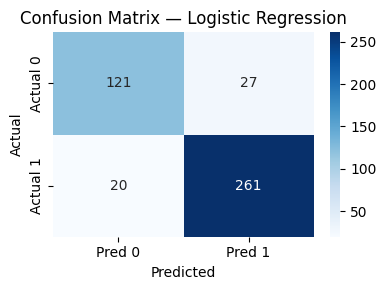

LR Confusion Matrix:
 [[121  27]
 [ 20 261]]


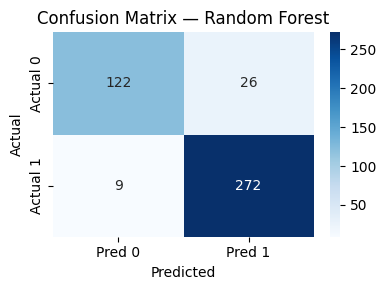

RF Confusion Matrix:
 [[122  26]
 [  9 272]]


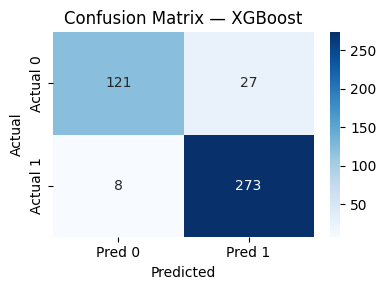

XGB Confusion Matrix:
 [[121  27]
 [  8 273]]


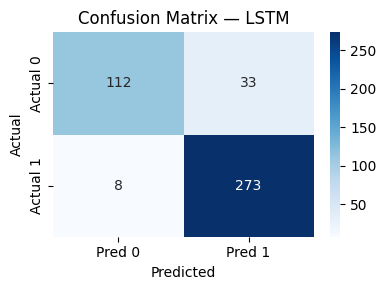

LSTM Confusion Matrix:
 [[112  33]
 [  8 273]]


In [120]:
# confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["Actual 0", "Actual 1"])
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()
    return cm

# -------------------------
# Logistic Regression
# -------------------------
cm_lr = plot_conf_matrix(y_test, pred_lr, "Confusion Matrix — Logistic Regression")
print("LR Confusion Matrix:\n", cm_lr)

# -------------------------
# Random Forest
# -------------------------
cm_rf = plot_conf_matrix(y_test, pred_rf, "Confusion Matrix — Random Forest")
print("RF Confusion Matrix:\n", cm_rf)

# -------------------------
# XGBoost
# -------------------------
cm_xgb = plot_conf_matrix(y_test, pred_xgb, "Confusion Matrix — XGBoost")
print("XGB Confusion Matrix:\n", cm_xgb)

# -------------------------
# LSTM (uses y_test_seq)
# -------------------------
cm_lstm = plot_conf_matrix(y_test_seq, pred_lstm, "Confusion Matrix — LSTM")
print("LSTM Confusion Matrix:\n", cm_lstm)

/tmp/ipython-input-3182128617.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xgb_importances, x="importance", y="feature", palette="viridis")


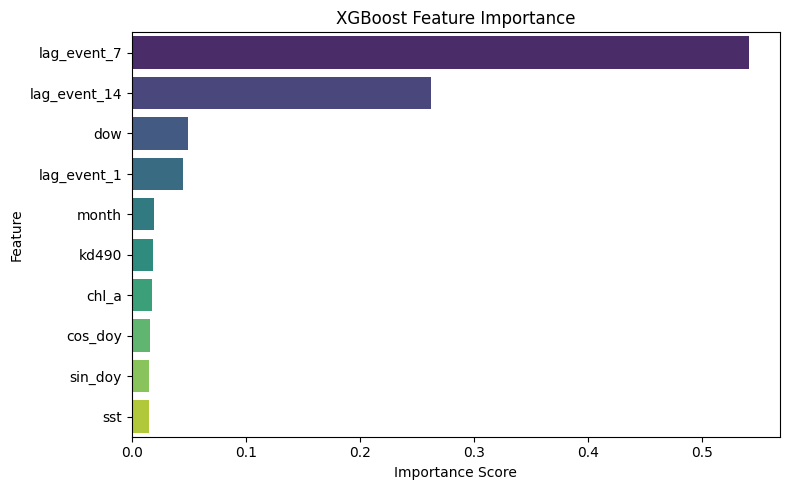

In [121]:
# feature importance plot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create DF with feature importances
xgb_importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=xgb_importances, x="importance", y="feature", palette="viridis")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Test date range: 2022-09-27 00:00:00 → 2023-12-01 00:00:00
Number of HAB days in test: 281
Window anchored on first HAB day in test set
Plotting window: 2022-10-03 00:00:00 → 2023-01-01 00:00:00
Points in window: 90


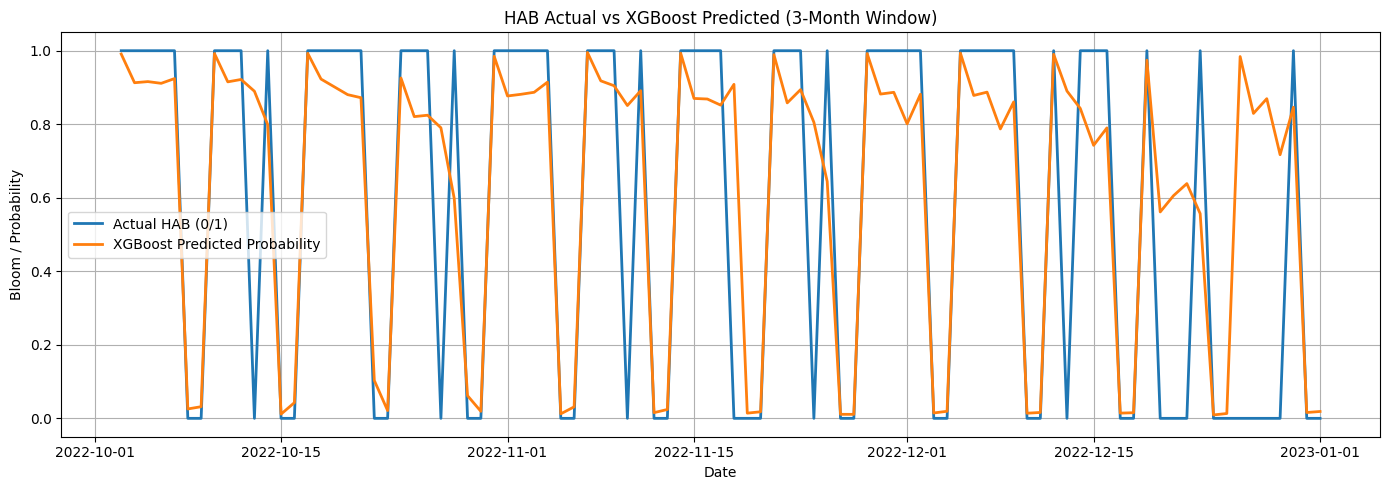

In [125]:
#model prediction vs reality
import pandas as pd
import matplotlib.pyplot as plt

# 1. Build a dataframe that lines up dates, actual labels, and predicted probs
#    df_fe must be the same dataframe you used to create X_train / X_test
test_dates = df_fe["date"].iloc[split_idx:].reset_index(drop=True)

plot_df = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.reset_index(drop=True),
    "predicted": proba_xgb
})

print("Test date range:", plot_df["date"].min(), "→", plot_df["date"].max())
print("Number of HAB days in test:", plot_df["actual"].sum())

# 2. Choose a 3-month window
#    First try to center it on the first day where a bloom actually happened.
bloom_days = plot_df[plot_df["actual"] == 1]

if len(bloom_days) > 0:
    # First actual bloom day in the test set
    start = bloom_days["date"].iloc[0]
    end = start + pd.Timedelta(days=90)
    window_reason = "Window anchored on first HAB day in test set"
else:
    # Fallback: no HAB days in test set → use highest-probability day instead
    top_day = plot_df.sort_values("predicted", ascending=False).iloc[0]
    center = top_day["date"]
    start = center - pd.Timedelta(days=45)
    end = center + pd.Timedelta(days=45)
    window_reason = "No HAB days in test; window centered on highest predicted risk day"

print(window_reason)
print("Plotting window:", start, "→", end)

# 3. Slice to that window
mask = (plot_df["date"] >= start) & (plot_df["date"] <= end)
plot_slice = plot_df[mask].copy()

print("Points in window:", len(plot_slice))

# 4. Make the plot (Actual vs Predicted)
plt.figure(figsize=(14, 5))
plt.plot(
    plot_slice["date"],
    plot_slice["actual"],
    label="Actual HAB (0/1)",
    linewidth=2
)
plt.plot(
    plot_slice["date"],
    plot_slice["predicted"],
    label="XGBoost Predicted Probability",
    linewidth=2
)

plt.title("HAB Actual vs XGBoost Predicted (3-Month Window)")
plt.xlabel("Date")
plt.ylabel("Bloom / Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()